In [1]:
# CELL 1 — imports, device, seeds, master CFG (paper-faithful + timm + augment)
# Checkpoint layout: ./checkpoints/{stage1,stage2,baseline}/<backbone>.pth
# !pip install timm   <-- run once if not already installed

import os, time, copy, random
from typing import Dict, Any, List, Tuple, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms
import timm

import torchquantum as tq
import torchquantum.functional as tqf

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_recall_fscore_support,
)
from sklearn.preprocessing import label_binarize


# ===== Reproducibility =====
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ===== Data paths =====
TRAIN_DIR = "/home/jovyan/ssh-test-datavol-1/dataset/dataset/train"
VAL_DIR   = "/home/jovyan/ssh-test-datavol-1/dataset/dataset/val"

# ===== Checkpoint folder layout =====
# ./checkpoints/
#     stage1/<backbone>.pth      <- Stage 1 (frontend+VQC+head trained from scratch)
#     stage2/<backbone>.pth      <- Stage 2 (Pre+<Backbone>-VQC, the proposed method)
#     baseline/<backbone>.pth    <- ImageNet-only baseline (Stage 2 schedule, no Stage 1 transfer)
CKPT_ROOT    = "./checkpoints"
STAGE1_DIR   = os.path.join(CKPT_ROOT, "stage1")
STAGE2_DIR   = os.path.join(CKPT_ROOT, "stage2")
BASELINE_DIR = os.path.join(CKPT_ROOT, "baseline")
for d in (CKPT_ROOT, STAGE1_DIR, STAGE2_DIR, BASELINE_DIR):
    os.makedirs(d, exist_ok=True)


def _safe_name(s: str) -> str:
    """timm names like 'vit_base_patch16_224.dino' -> safe filename 'vit_base_patch16_224_dino'."""
    return s.replace("/", "__").replace(".", "_").replace(":", "_")




CFG: Dict[str, Any] = {
    # ===== Backbone (any timm model name) =====
    "backbone":    "resnet34",
    "pretrained":  True,
    # ===== Quantum (DO NOT CHANGE — paper-fixed) =====
    "n_qubits":    8,
    "n_qlayers":   1,
    "n_classes":   3,
    "class_names": ["no", "sphere", "vort"],
    # ===== Inputs / cache =====
    "input_size":   150,
    "resize_to":    224,
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std":  [0.229, 0.224, 0.225],
    # ===== Loaders =====
    "batch_size":  256,
    "test_split":  0.10,
    # ===== Loss / regularization / schedule =====
    "class_weights":    [1.0, 2.5, 2.0],   # set [1,1,1] to disable weighting
    "grad_clip":        1.0,
    "warmup_epochs":    3,                 # tuned for ResNet-34: shorter cold-start
    "use_augmentation": True,
    # ===== Stage 1 LRs (frontend + VQC + head trained from scratch) =====
    "stage1_epochs":      60,
    "stage1_wd":          5e-4,
    "stage1_lr_backbone": 2e-4,            # preserve ImageNet features in pretrained ResNet-34
    "stage1_lr_bridge":   1e-3,            # random bridge MLP, full lr
    "stage1_lr_quantum":  5e-3,            # random VQC + head, full lr
    # ===== Stage 2 LRs (load frontend only, reset VQC + head) =====
    "stage2_epochs": 60,
    "stage2_wd":     1e-4,
    "lr_backbone":   1e-4,                 # halved vs Stage 1: trunk is already lensing-tuned
    "lr_bridge":     5e-4,                 # bridge is also loaded -> gentler than Stage 1
    "lr_quantum":    5e-3,                 # VQC + head are fresh again -> full lr
    "seed": SEED,
}
# Derive checkpoint paths from backbone name (so swapping backbones doesn't overwrite earlier runs)
_bb = _safe_name(CFG["backbone"])
CFG["stage1_ckpt"]   = os.path.join(STAGE1_DIR,   f"{_bb}.pth")
CFG["stage2_ckpt"]   = os.path.join(STAGE2_DIR,   f"{_bb}.pth")
CFG["baseline_ckpt"] = os.path.join(BASELINE_DIR, f"{_bb}.pth")
print(f"PyTorch {torch.__version__} | TorchQuantum {tq.__version__} | timm {timm.__version__}")
print(f"Device: {device} | CUDA: {torch.cuda.is_available()}")
print(f"Backbone: {CFG['backbone']}  pretrained={CFG['pretrained']}")
print(f"Stage 1 LRs: backbone={CFG['stage1_lr_backbone']} bridge={CFG['stage1_lr_bridge']} quantum={CFG['stage1_lr_quantum']}")
print(f"Stage 2 LRs: backbone={CFG['lr_backbone']} bridge={CFG['lr_bridge']} quantum={CFG['lr_quantum']}")
print(f"class_weights={CFG['class_weights']}, grad_clip={CFG['grad_clip']}, "
      f"warmup={CFG['warmup_epochs']}, use_augmentation={CFG['use_augmentation']}")
print(f"\nCheckpoint layout:")
print(f"  stage1   -> {CFG['stage1_ckpt']}")
print(f"  stage2   -> {CFG['stage2_ckpt']}")
print(f"  baseline -> {CFG['baseline_ckpt']}")


PyTorch 2.5.1+cu124 | TorchQuantum 0.1.8 | timm 1.0.26
Device: cuda:0 | CUDA: True
Backbone: resnet34  pretrained=True
Stage 1 LRs: backbone=0.0002 bridge=0.001 quantum=0.005
Stage 2 LRs: backbone=0.0001 bridge=0.0005 quantum=0.005
class_weights=[1.0, 2.5, 2.0], grad_clip=1.0, warmup=3, use_augmentation=True

Checkpoint layout:
  stage1   -> ./checkpoints/stage1/resnet34.pth
  stage2   -> ./checkpoints/stage2/resnet34.pth
  baseline -> ./checkpoints/baseline/resnet34.pth


In [2]:
# CELL 2 — preprocess once on GPU, serve at memcpy speed; label-preserving augmentation

class GPUTensorDataset:
    def __init__(self, cache: torch.Tensor, labels: torch.Tensor, classes: List[str]):
        self.cache  = cache
        self.labels = labels
        self.classes = classes
    def __len__(self) -> int:
        return self.cache.size(0)


class GPULoader:
    def __init__(self, dataset: GPUTensorDataset, batch_size: int,
                 shuffle: bool = False, seed: int = 42):
        self.dataset = dataset
        self.bs = batch_size
        self.shuffle = shuffle
        self.seed = seed
        self._epoch = 0

    def __len__(self) -> int:
        return (len(self.dataset) + self.bs - 1) // self.bs

    def __iter__(self):
        n   = len(self.dataset)
        dev = self.dataset.cache.device
        if self.shuffle:
            g = torch.Generator(); g.manual_seed(self.seed + self._epoch)
            perm = torch.randperm(n, generator=g).to(dev)
        else:
            perm = torch.arange(n, device=dev)
        self._epoch += 1
        cache, labels = self.dataset.cache, self.dataset.labels
        for i in range(0, n, self.bs):
            idx = perm[i:i + self.bs]
            yield cache.index_select(0, idx).float(), labels.index_select(0, idx)


def build_gpu_cache(root_dir, resize_to, mean, std, device,
                    dtype: torch.dtype = torch.float32, chunk: int = 256):
    classes = sorted([d for d in os.listdir(root_dir)
                      if os.path.isdir(os.path.join(root_dir, d))])
    class_to_idx = {c: i for i, c in enumerate(classes)}
    files: List[Tuple[str, int]] = []
    for c in classes:
        cdir = os.path.join(root_dir, c)
        for f in os.listdir(cdir):
            if f.endswith(".npy"):
                files.append((os.path.join(cdir, f), class_to_idx[c]))

    N = len(files)
    cache  = torch.empty((N, 3, resize_to, resize_to), dtype=dtype,        device=device)
    labels = torch.empty((N,),                          dtype=torch.long, device=device)
    m = torch.tensor(mean, device=device, dtype=torch.float32).view(1, 3, 1, 1)
    s = torch.tensor(std,  device=device, dtype=torch.float32).view(1, 3, 1, 1)

    print(f"Caching {N} samples from {root_dir} -> GPU 3x{resize_to}x{resize_to} {dtype}")
    for cs in tqdm(range(0, N, chunk), desc="cache build"):
        ce = min(cs + chunk, N)
        cpu_imgs, cpu_lbls = [], []
        for fp, lbl in files[cs:ce]:
            arr = np.load(fp)
            if arr.ndim == 2:
                arr = arr[np.newaxis, :, :]
            elif arr.ndim == 3 and arr.shape[0] not in (1, 3):
                arr = arr.transpose(2, 0, 1)
            if arr.max() > 1.0:
                arr = arr / 255.0
            t = torch.from_numpy(np.ascontiguousarray(arr)).float()
            if t.shape[0] == 1:
                t = t.repeat(3, 1, 1)
            cpu_imgs.append(t)
            cpu_lbls.append(lbl)
        batch = torch.stack(cpu_imgs, dim=0).to(device, non_blocking=True)
        batch = F.interpolate(batch, size=(resize_to, resize_to),
                              mode="bilinear", align_corners=False)
        batch = (batch - m) / s
        cache[cs:ce]  = batch.to(dtype)
        labels[cs:ce] = torch.tensor(cpu_lbls, dtype=torch.long, device=device)
    return GPUTensorDataset(cache, labels, classes)


class GPUAugment(nn.Module):
    """Per-sample h/v flips + per-batch 90-deg rotation. All label-preserving."""
    def __init__(self, p_hflip: float = 0.5, p_vflip: float = 0.5, p_rot90: float = 0.75):
        super().__init__()
        self.p_hflip = p_hflip
        self.p_vflip = p_vflip
        self.p_rot90 = p_rot90

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.shape[0]; dev = x.device
        m = (torch.rand(B, device=dev) < self.p_hflip).view(B, 1, 1, 1)
        x = torch.where(m, x.flip(-1), x)
        m = (torch.rand(B, device=dev) < self.p_vflip).view(B, 1, 1, 1)
        x = torch.where(m, x.flip(-2), x)
        if torch.rand(1, device=dev).item() < self.p_rot90:
            k = int(torch.randint(1, 4, (1,)).item())
            x = torch.rot90(x, k, dims=[-2, -1])
        return x


# === build caches and loaders ===
CACHE_DTYPE = torch.float32
t0 = time.time()
train_set = build_gpu_cache(TRAIN_DIR, CFG["resize_to"], CFG["imagenet_mean"], CFG["imagenet_std"],
                            device, dtype=CACHE_DTYPE)
val_full  = build_gpu_cache(VAL_DIR, CFG["resize_to"], CFG["imagenet_mean"], CFG["imagenet_std"],
                            device, dtype=CACHE_DTYPE)
print(f"Cache build took {time.time()-t0:.1f}s | "
      f"GPU mem allocated {torch.cuda.memory_allocated()/1e9:.2f} GB")

g = torch.Generator().manual_seed(CFG["seed"])
n_total = len(val_full); n_test = int(n_total * CFG["test_split"])
perm = torch.randperm(n_total, generator=g)
val_idx, test_idx = perm[n_test:].to(device), perm[:n_test].to(device)
val_set  = GPUTensorDataset(val_full.cache.index_select(0, val_idx),
                            val_full.labels.index_select(0, val_idx), val_full.classes)
test_set = GPUTensorDataset(val_full.cache.index_select(0, test_idx),
                            val_full.labels.index_select(0, test_idx), val_full.classes)
del val_full; torch.cuda.empty_cache()

train_loader = GPULoader(train_set, batch_size=CFG["batch_size"], shuffle=True,  seed=CFG["seed"])
val_loader   = GPULoader(val_set,   batch_size=CFG["batch_size"], shuffle=False)
test_loader  = GPULoader(test_set,  batch_size=CFG["batch_size"], shuffle=False)

augmenter = GPUAugment().to(device) if CFG["use_augmentation"] else None
print(f"Augmentation: {'ON' if augmenter is not None else 'OFF'}")

CLASS_NAMES = train_set.classes
assert CLASS_NAMES == CFG["class_names"], f"class mismatch: {CLASS_NAMES}"
print(f"Sizes: train={len(train_set)} val={len(val_set)} test={len(test_set)}")

import collections
counts = collections.Counter(train_set.labels.cpu().tolist())
print("Class counts (train):", {CLASS_NAMES[k]: v for k, v in sorted(counts.items())})

Caching 30000 samples from /home/jovyan/ssh-test-datavol-1/dataset/dataset/train -> GPU 3x224x224 torch.float32


cache build:   0%|          | 0/118 [00:00<?, ?it/s]

Caching 7500 samples from /home/jovyan/ssh-test-datavol-1/dataset/dataset/val -> GPU 3x224x224 torch.float32


cache build:   0%|          | 0/30 [00:00<?, ?it/s]

Cache build took 689.9s | GPU mem allocated 22.58 GB
Augmentation: ON
Sizes: train=30000 val=6750 test=750
Class counts (train): {'no': 10000, 'sphere': 10000, 'vort': 10000}


In [3]:
# CELL 3 — VQC ansatz: RY encode + (RX,RY,RZ + CNOT ring) x n_qlayers + PauliZ measure

class VQC(tq.QuantumModule):
    def __init__(self, n_wires: int = 8, n_qlayers: int = 1):
        super().__init__()
        self.n_wires = n_wires
        self.n_qlayers = n_qlayers
        self.encoder = tq.GeneralEncoder([
            {"input_idx": [i], "func": "ry", "wires": [i]} for i in range(n_wires)
        ])
        self.params_rx_dct = tq.QuantumModuleDict()
        self.params_ry_dct = tq.QuantumModuleDict()
        self.params_rz_dct = tq.QuantumModuleDict()
        for k in range(n_qlayers):
            for i in range(n_wires):
                key = str(i + k * n_wires)
                self.params_rx_dct[key] = tq.RX(has_params=True, trainable=True)
                self.params_ry_dct[key] = tq.RY(has_params=True, trainable=True)
                self.params_rz_dct[key] = tq.RZ(has_params=True, trainable=True)
        self.measure = tq.MeasureAll(tq.PauliZ)

    @tq.static_support
    def forward(self, x: torch.Tensor, q_device: tq.QuantumDevice):
        self.q_device = q_device
        self.encoder(self.q_device, x)
        for k in range(self.n_qlayers):
            for i in range(self.n_wires):
                key = str(i + k * self.n_wires)
                self.params_rx_dct[key](self.q_device, wires=i)
                self.params_ry_dct[key](self.q_device, wires=i)
                self.params_rz_dct[key](self.q_device, wires=i)
            for i in range(self.n_wires):
                tgt = 0 if i == self.n_wires - 1 else i + 1
                tqf.cnot(self.q_device, wires=[i, tgt],
                         static=self.static_mode, parent_graph=self.graph)
        return self.measure(self.q_device)

In [4]:
# CELL 4 — pluggable backbone via timm.create_model (any timm model name works)

def _make_bridge(in_dim: int, n_qubits: int, dropout: float = 0.2) -> nn.Sequential:
    dims = [in_dim, 256, 128, 64, 32, n_qubits]
    layers: List[nn.Module] = []
    for i in range(len(dims) - 2):
        d = dropout * (1.0 - 0.2 * i)
        layers += [
            nn.Linear(dims[i], dims[i + 1]),
            nn.BatchNorm1d(dims[i + 1]),
            nn.ReLU(inplace=True),
            nn.Dropout(d),
        ]
    layers.append(nn.Linear(dims[-2], dims[-1]))
    seq = nn.Sequential(*layers)
    for m in seq.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return seq


class TimmFrontEnd(nn.Module):
    """Any timm-supported pretrained trunk -> bridge MLP -> n_qubits."""
    def __init__(self, name: str, n_qubits: int, pretrained: bool = True):
        super().__init__()
        self.backbone = timm.create_model(name, pretrained=pretrained, num_classes=0)
        self.feat_dim = self.backbone.num_features
        self.n_qubits = n_qubits
        self.bridge   = _make_bridge(in_dim=self.feat_dim, n_qubits=n_qubits, dropout=0.2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.bridge(self.backbone(x))


def get_frontend(name: str, n_qubits: int, pretrained: bool = True) -> nn.Module:
    return TimmFrontEnd(name, n_qubits=n_qubits, pretrained=pretrained)


_fe = get_frontend(CFG["backbone"], n_qubits=CFG["n_qubits"], pretrained=CFG["pretrained"]).to(device)
_xb = torch.randn(2, 3, CFG["resize_to"], CFG["resize_to"], device=device)
_yb = _fe(_xb)
data_cfg = timm.data.resolve_model_data_config(_fe.backbone)
print(f"backbone     : {CFG['backbone']}")
print(f"feat_dim     : {_fe.feat_dim} -> n_qubits={_fe.n_qubits}")
print(f"output shape : {tuple(_yb.shape)} (expected (2, {CFG['n_qubits']}))")
print(f"timm cfg     : input={data_cfg.get('input_size')}, "
      f"mean={data_cfg.get('mean')}, std={data_cfg.get('std')}")
print(f"trainable    : {sum(p.numel() for p in _fe.parameters() if p.requires_grad):,}")
del _fe, _xb, _yb

backbone     : resnet34
feat_dim     : 512 -> n_qubits=8
output shape : (2, 8) (expected (2, 8))
timm cfg     : input=(3, 224, 224), mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)
trainable    : 21,460,456


In [5]:
# CELL 5 — Stage 1 model: same architecture as Stage 2 (vqc_classifier.py:TTN_VQC analog)

class Stage1Model(nn.Module):
    """frontend -> sigmoid*pi/2 -> VQC -> Linear(n_qubits, n_classes) -> log_softmax"""
    def __init__(self, frontend: nn.Module, n_qubits: int, n_qlayers: int, n_classes: int):
        super().__init__()
        self.frontend = frontend
        self.n_qubits = n_qubits
        self.vqc  = VQC(n_wires=n_qubits, n_qlayers=n_qlayers)
        self.head = nn.Linear(n_qubits, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        bsz = x.shape[0]
        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=x.device)
        pre_out = self.frontend(x)
        q_in = torch.sigmoid(pre_out) * (np.pi / 2.0)
        q_out = self.vqc(q_in, qdev)
        return F.log_softmax(self.head(q_out), dim=1)


def build_stage1_model(cfg: Dict[str, Any]) -> Stage1Model:
    fe = get_frontend(cfg["backbone"], cfg["n_qubits"], pretrained=cfg["pretrained"])
    return Stage1Model(fe, n_qubits=cfg["n_qubits"],
                       n_qlayers=cfg["n_qlayers"], n_classes=cfg["n_classes"])


_m = build_stage1_model(CFG).to(device)
_xb = torch.randn(2, 3, CFG["resize_to"], CFG["resize_to"], device=device)
_yb = _m(_xb)
print(f"Stage1Model out shape: {tuple(_yb.shape)} (expected (2, {CFG['n_classes']}))")
print(f"Stage1Model params: {sum(p.numel() for p in _m.parameters()):,}")
print(f"  backbone : {sum(p.numel() for p in _m.frontend.backbone.parameters()):,}")
print(f"  bridge   : {sum(p.numel() for p in _m.frontend.bridge.parameters()):,}")
print(f"  vqc      : {sum(p.numel() for p in _m.vqc.parameters()):,}")
print(f"  head     : {sum(p.numel() for p in _m.head.parameters()):,}")
del _m, _xb, _yb

Stage1Model out shape: (2, 3) (expected (2, 3))
Stage1Model params: 21,460,507
  backbone : 21,284,672
  bridge   : 175,784
  vqc      : 24
  head     : 27


In [6]:
# CELL 6 — Stage 1 training (paper-faithful, with augmentation, weighted NLL, grad clip)

def get_stage1_param_groups(model: Stage1Model, cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    return [
        {"params": list(model.frontend.backbone.parameters()),
         "lr": cfg["stage1_lr_backbone"], "name": "backbone"},
        {"params": list(model.frontend.bridge.parameters()),
         "lr": cfg["stage1_lr_bridge"],   "name": "bridge"},
        {"params": list(model.vqc.parameters()) + list(model.head.parameters()),
         "lr": cfg["stage1_lr_quantum"],  "name": "quantum"},
    ]


def warmup_cosine_factor(epoch: int, warmup: int, total: int) -> float:
    if warmup > 0 and epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(1, total - warmup)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


def run_stage1(cfg, train_loader, val_loader, augmenter: Optional[nn.Module] = None):
    torch.manual_seed(cfg["seed"])
    model = build_stage1_model(cfg).to(device)

    cw = cfg.get("class_weights")
    if cw is not None and any(w != 1.0 for w in cw):
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)
        criterion = nn.NLLLoss(weight=cw_t)
        print(f"[S1] using class weights {cw}")
    else:
        criterion = nn.NLLLoss()

    optimizer = optim.Adam(get_stage1_param_groups(model, cfg), weight_decay=cfg["stage1_wd"])
    scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda e: warmup_cosine_factor(e, cfg["warmup_epochs"], cfg["stage1_epochs"]),
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = -1.0, None
    print(f"[S1] paper-faithful: frontend + VQC + Linear({cfg['n_qubits']}->{cfg['n_classes']})")
    print(f"[S1] augmentation: {'ON' if augmenter is not None else 'OFF'}")
    print(f"[S1] trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    for epoch in range(cfg["stage1_epochs"]):
        model.train()
        tr_loss = tr_correct = tr_total = 0
        pbar = tqdm(train_loader, desc=f"[S1] ep {epoch+1}/{cfg['stage1_epochs']}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if augmenter is not None and model.training:
                xb = augmenter(xb)
            optimizer.zero_grad(set_to_none=True)
            logp = model(xb)
            loss = criterion(logp, yb)
            loss.backward()
            if cfg.get("grad_clip"):
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            tr_loss    += loss.item() * xb.size(0)
            tr_correct += (logp.argmax(1) == yb).sum().item()
            tr_total   += xb.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss, train_acc = tr_loss / tr_total, tr_correct / tr_total

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logp = model(xb)
                v_loss    += criterion(logp, yb).item() * xb.size(0)
                v_correct += (logp.argmax(1) == yb).sum().item()
                v_total   += xb.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"],
                        [train_loss, train_acc, val_loss, val_acc]):
            history[k].append(v)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, cfg["stage1_ckpt"])

        scheduler.step()
        lrs = " ".join(f"{g['name']}={g['lr']:.1e}" for g in optimizer.param_groups)
        print(f"[S1] ep {epoch+1:02d}/{cfg['stage1_epochs']} | {lrs} | "
              f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} {'*' if is_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\n[S1] Best val acc: {best_val_acc:.4f}")
    print(f"[S1] Saved best ckpt: {cfg['stage1_ckpt']}")
    return model, history


t0 = time.time()
stage1_model, stage1_history = run_stage1(CFG, train_loader, val_loader, augmenter=augmenter)
print(f"[S1] total time: {(time.time()-t0)/60:.1f} min")

[S1] using class weights [1.0, 2.5, 2.0]
[S1] paper-faithful: frontend + VQC + Linear(8->3)
[S1] augmentation: ON
[S1] trainable params: 21,460,507


[S1] ep 1/60:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 01/60 | backbone=1.3e-04 bridge=6.7e-04 quantum=3.3e-03 | train loss=1.1127 acc=0.3329 | val loss=1.0604 acc=0.3336 *


[S1] ep 2/60:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 02/60 | backbone=2.0e-04 bridge=1.0e-03 quantum=5.0e-03 | train loss=1.0409 acc=0.3334 | val loss=1.0407 acc=0.3335 


...

[S1] ep 58/60 | backbone=6.1e-07 bridge=3.0e-06 quantum=1.5e-05 | train loss=0.0792 acc=0.9757 | val loss=0.1810 acc=0.9513 


[S1] ep 59/60:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 59/60 | backbone=1.5e-07 bridge=7.6e-07 quantum=3.8e-06 | train loss=0.0750 acc=0.9777 | val loss=0.1962 acc=0.9477 


[S1] ep 60/60:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 60/60 | backbone=0.0e+00 bridge=0.0e+00 quantum=0.0e+00 | train loss=0.0744 acc=0.9769 | val loss=0.1817 acc=0.9524 *

[S1] Best val acc: 0.9524
[S1] Saved best ckpt: ./checkpoints/stage1/resnet34.pth
[S1] total time: 11.4 min


eval:   0%|          | 0/3 [00:00<?, ?it/s]


=== Stage 1 (paper-faithful: frontend+VQC+head trained from scratch) ===
Test accuracy: 0.9587
Macro ROC-AUC: 0.9919
              precision    recall  f1-score   support

          no     0.9300    0.9869    0.9576       229
      sphere     0.9588    0.9357    0.9472       249
        vort     0.9848    0.9559    0.9701       272

    accuracy                         0.9587       750
   macro avg     0.9579    0.9595    0.9583       750
weighted avg     0.9595    0.9587    0.9587       750



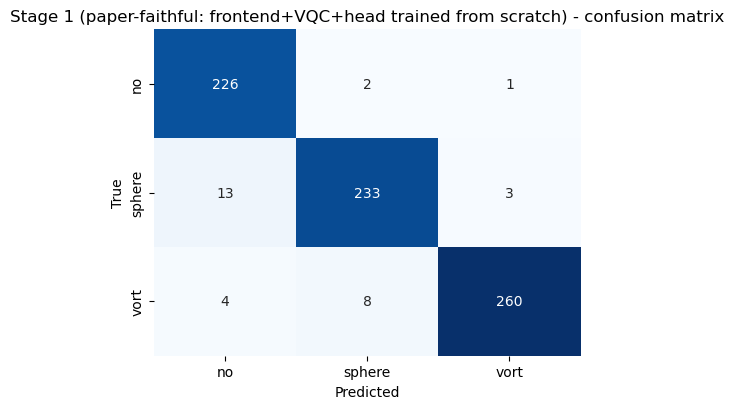

In [7]:
# CELL 7 — Shared eval helpers + Stage 1 test-set evaluation

@torch.no_grad()
def collect_predictions(model: nn.Module, loader, dev):
    model.eval()
    all_logp, all_y = [], []
    for xb, yb in tqdm(loader, desc="eval", leave=False):
        xb = xb.to(dev, non_blocking=True)
        all_logp.append(model(xb).detach().cpu())
        all_y.append(yb.detach().cpu())
    logp  = torch.cat(all_logp, dim=0).numpy()
    y     = torch.cat(all_y,    dim=0).numpy()
    probs = np.exp(logp)
    return probs, probs.argmax(axis=1), y


def plot_confusion(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(5.0, 4.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout(); plt.show()


def evaluate_classifier(model, loader, class_names, tag: str):
    probs, preds, y = collect_predictions(model, loader, device)
    acc = accuracy_score(y, preds)
    y_bin = label_binarize(y, classes=list(range(len(class_names))))
    macro_auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    cm = confusion_matrix(y, preds)
    print(f"\n=== {tag} ===")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Macro ROC-AUC: {macro_auc:.4f}")
    print(classification_report(y, preds, target_names=class_names, digits=4))
    plot_confusion(cm, class_names, title=f"{tag} - confusion matrix")
    return {"tag": tag, "accuracy": acc, "macro_auc": macro_auc,
            "probs": probs, "preds": preds, "targets": y}


stage1_results = evaluate_classifier(
    stage1_model, test_loader, CLASS_NAMES,
    tag="Stage 1 (paper-faithful: frontend+VQC+head trained from scratch)")

In [8]:
# CELL 8 — Stage 2 model (vqc_finetune.py:VQC_FINETUNE analog)

class Stage2Model(nn.Module):
    """frontend (loaded) -> sigmoid*pi/2 -> VQC (fresh) -> Linear (fresh) -> log_softmax"""
    def __init__(self, frontend: nn.Module, n_qubits: int, n_qlayers: int, n_classes: int):
        super().__init__()
        self.frontend = frontend
        self.n_qubits = n_qubits
        self.vqc  = VQC(n_wires=n_qubits, n_qlayers=n_qlayers)
        self.head = nn.Linear(n_qubits, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        bsz = x.shape[0]
        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=x.device)
        pre_out = self.frontend(x)
        q_in = torch.sigmoid(pre_out) * (np.pi / 2.0)
        q_out = self.vqc(q_in, qdev)
        return F.log_softmax(self.head(q_out), dim=1)


def build_stage2_model(cfg) -> Stage2Model:
    fe = get_frontend(cfg["backbone"], cfg["n_qubits"], pretrained=cfg["pretrained"])
    return Stage2Model(fe, n_qubits=cfg["n_qubits"],
                       n_qlayers=cfg["n_qlayers"], n_classes=cfg["n_classes"])

In [9]:
# CELL 9 — Mirrors vqc_finetune.py:180-192: prefix-strip + key-by-key copy

def load_frontend_from_stage1(stage2_model: Stage2Model,
                              stage1_ckpt_path: str,
                              strict: bool = True) -> Stage2Model:
    saved = torch.load(stage1_ckpt_path, map_location="cpu", weights_only=True)
    fe_state = stage2_model.frontend.state_dict()
    fe_from_saved = {
        k[len("frontend."):]: v for k, v in saved.items() if k.startswith("frontend.")
    }
    n_loaded = 0
    for k in fe_state.keys():
        if k in fe_from_saved and fe_from_saved[k].shape == fe_state[k].shape:
            fe_state[k] = fe_from_saved[k]
            n_loaded += 1
    result = stage2_model.frontend.load_state_dict(fe_state, strict=strict)
    n_skipped = sum(1 for k in saved if not k.startswith("frontend."))
    print(f"[FE-load] frontend keys loaded: {n_loaded}/{len(fe_state)}")
    print(f"[FE-load] non-frontend keys (vqc.* / head.*) skipped: {n_skipped}")
    if getattr(result, "missing_keys", []):
        print(f"  missing:    {result.missing_keys}")
    if getattr(result, "unexpected_keys", []):
        print(f"  unexpected: {result.unexpected_keys}")
    return stage2_model

In [10]:
# CELL 10 — Stage 2 training: load frontend only, reset VQC + head, fine-tune

def get_stage2_param_groups(model: Stage2Model, cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    return [
        {"params": list(model.frontend.backbone.parameters()),
         "lr": cfg["lr_backbone"], "name": "backbone"},
        {"params": list(model.frontend.bridge.parameters()),
         "lr": cfg["lr_bridge"],   "name": "bridge"},
        {"params": list(model.vqc.parameters()) + list(model.head.parameters()),
         "lr": cfg["lr_quantum"],  "name": "quantum"},
    ]


def run_stage2(cfg, train_loader, val_loader, load_stage1: bool,
               ckpt_save_path: str, run_tag: str,
               augmenter: Optional[nn.Module] = None):
    torch.manual_seed(cfg["seed"])
    model = build_stage2_model(cfg).to(device)
    if load_stage1:
        model = load_frontend_from_stage1(model, cfg["stage1_ckpt"], strict=True)
    else:
        print(f"[{run_tag}] Skipping Stage-1 weights -> ImageNet-only.")

    cw = cfg.get("class_weights")
    if cw is not None and any(w != 1.0 for w in cw):
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)
        criterion = nn.NLLLoss(weight=cw_t)
    else:
        criterion = nn.NLLLoss()

    optimizer = optim.Adam(get_stage2_param_groups(model, cfg), weight_decay=cfg["stage2_wd"])
    scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda e: warmup_cosine_factor(e, cfg["warmup_epochs"], cfg["stage2_epochs"]),
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = -1.0, None
    print(f"[{run_tag}] augmentation: {'ON' if augmenter is not None else 'OFF'}")

    for epoch in range(cfg["stage2_epochs"]):
        model.train()
        tr_loss = tr_correct = tr_total = 0
        pbar = tqdm(train_loader, desc=f"[{run_tag}] ep {epoch+1}/{cfg['stage2_epochs']}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if augmenter is not None and model.training:
                xb = augmenter(xb)
            optimizer.zero_grad(set_to_none=True)
            logp = model(xb)
            loss = criterion(logp, yb)
            loss.backward()
            if cfg.get("grad_clip"):
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            tr_loss    += loss.item() * xb.size(0)
            tr_correct += (logp.argmax(1) == yb).sum().item()
            tr_total   += xb.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss, train_acc = tr_loss / tr_total, tr_correct / tr_total

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logp = model(xb)
                v_loss    += criterion(logp, yb).item() * xb.size(0)
                v_correct += (logp.argmax(1) == yb).sum().item()
                v_total   += xb.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"],
                        [train_loss, train_acc, val_loss, val_acc]):
            history[k].append(v)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, ckpt_save_path)

        scheduler.step()
        lrs = " ".join(f"{g['name']}={g['lr']:.1e}" for g in optimizer.param_groups)
        print(f"[{run_tag}] ep {epoch+1:02d}/{cfg['stage2_epochs']} | {lrs} | "
              f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} {'*' if is_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\n[{run_tag}] Best val acc: {best_val_acc:.4f}")
    print(f"[{run_tag}] Saved best ckpt: {ckpt_save_path}")
    return model, history


t0 = time.time()
pre_vqc_model, pre_vqc_history = run_stage2(
    CFG, train_loader, val_loader,
    load_stage1=True,
    ckpt_save_path=CFG["stage2_ckpt"],
    run_tag=f"Pre+{CFG['backbone']}-VQC",
    augmenter=augmenter,
)
print(f"[Pre+{CFG['backbone']}-VQC] total time: {(time.time()-t0)/60:.1f} min")

[FE-load] frontend keys loaded: 246/246
[FE-load] non-frontend keys (vqc.* / head.*) skipped: 28
[Pre+resnet34-VQC] augmentation: ON


[Pre+resnet34-VQC] ep 1/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+resnet34-VQC] ep 01/60 | backbone=6.7e-05 bridge=3.3e-04 quantum=3.3e-03 | train loss=1.0394 acc=0.5861 | val loss=0.9396 acc=0.6166 *


[Pre+resnet34-VQC] ep 2/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+resnet34-VQC] ep 02/60 | backbone=1.0e-04 bridge=5.0e-04 quantum=5.0e-03 | train loss=0.6604 acc=0.6587 | val loss=0.5233 acc=0.6218 *


...

[Pre+resnet34-VQC] ep 58/60 | backbone=3.0e-07 bridge=1.5e-06 quantum=1.5e-05 | train loss=0.0434 acc=0.9857 | val loss=0.1958 acc=0.9573 


[Pre+resnet34-VQC] ep 59/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+resnet34-VQC] ep 59/60 | backbone=7.6e-08 bridge=3.8e-07 quantum=3.8e-06 | train loss=0.0470 acc=0.9856 | val loss=0.2311 acc=0.9526 


[Pre+resnet34-VQC] ep 60/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+resnet34-VQC] ep 60/60 | backbone=0.0e+00 bridge=0.0e+00 quantum=0.0e+00 | train loss=0.0430 acc=0.9860 | val loss=0.1947 acc=0.9578 

[Pre+resnet34-VQC] Best val acc: 0.9584
[Pre+resnet34-VQC] Saved best ckpt: ./checkpoints/stage2/resnet34.pth
[Pre+resnet34-VQC] total time: 11.3 min


eval:   0%|          | 0/3 [00:00<?, ?it/s]


=== Pre+resnet34-VQC ===
Test accuracy: 0.9600
Macro ROC-AUC: 0.9936
Macro P/R/F1: 0.9593 / 0.9610 / 0.9598
              precision    recall  f1-score   support

          no     0.9380    0.9913    0.9639       229
      sphere     0.9549    0.9357    0.9452       249
        vort     0.9848    0.9559    0.9701       272

    accuracy                         0.9600       750
   macro avg     0.9593    0.9610    0.9598       750
weighted avg     0.9606    0.9600    0.9600       750



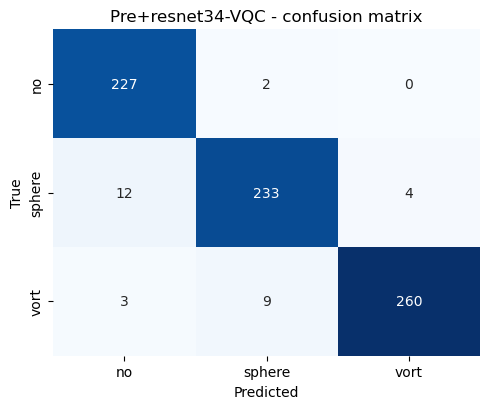

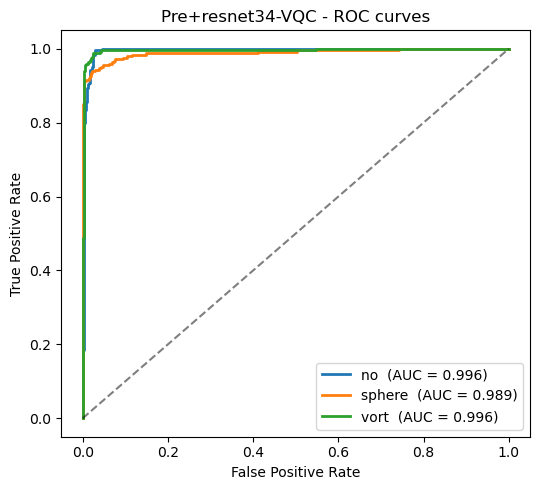

In [11]:
# CELL 11 — Stage 2 full evaluation: per-class P/R/F1, ROC curves, confusion matrix

def plot_roc_curves(probs, y, class_names, title):
    n_cls = len(class_names)
    y_bin = label_binarize(y, classes=list(range(n_cls)))
    fig, ax = plt.subplots(figsize=(5.5, 5.0))
    for i, cname in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        ax.plot(fpr, tpr, lw=2, label=f"{cname}  (AUC = {auc(fpr, tpr):.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(title); ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()


def evaluate_full(model, loader, class_names, tag: str):
    probs, preds, y = collect_predictions(model, loader, device)
    acc = accuracy_score(y, preds)
    y_bin = label_binarize(y, classes=list(range(len(class_names))))
    macro_auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    p, r, f1, _ = precision_recall_fscore_support(y, preds, average=None, zero_division=0)
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(y, preds, average="macro", zero_division=0)
    cm = confusion_matrix(y, preds)
    print(f"\n=== {tag} ===")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Macro ROC-AUC: {macro_auc:.4f}")
    print(f"Macro P/R/F1: {p_m:.4f} / {r_m:.4f} / {f1_m:.4f}")
    print(classification_report(y, preds, target_names=class_names, digits=4))
    plot_confusion(cm, class_names, title=f"{tag} - confusion matrix")
    plot_roc_curves(probs, y, class_names, title=f"{tag} - ROC curves")
    return {
        "tag": tag, "accuracy": acc, "macro_auc": macro_auc,
        "macro_precision": p_m, "macro_recall": r_m, "macro_f1": f1_m,
        "per_class_precision": dict(zip(class_names, p.tolist())),
        "per_class_recall":    dict(zip(class_names, r.tolist())),
        "per_class_f1":        dict(zip(class_names, f1.tolist())),
        "probs": probs, "preds": preds, "targets": y,
    }


pre_vqc_results = evaluate_full(
    pre_vqc_model, test_loader, CLASS_NAMES,
    tag=f"Pre+{CFG['backbone']}-VQC")

In [12]:
# # CELL 12 — Baseline: same Stage-2 schedule but front-end stays at ImageNet weights only

# t0 = time.time()
# baseline_model, baseline_history = run_stage2(
#     CFG, train_loader, val_loader,
#     load_stage1=False,
#     ckpt_save_path=CFG["baseline_ckpt"],
#     run_tag=f"ImageNet-only-{CFG['backbone']}-VQC",
#     augmenter=augmenter,
# )
# print(f"[ImageNet-only-{CFG['backbone']}-VQC] total time: {(time.time()-t0)/60:.1f} min")

# baseline_results = evaluate_full(
#     baseline_model, test_loader, CLASS_NAMES,
#     tag=f"ImageNet-only-{CFG['backbone']}-VQC")

In [13]:
# CELL 13 - Pure classical model: same frontend + bridge as Stage 1/2 but NO VQC

class ClassicalModel(nn.Module):
    """
    Pure-classical baseline:
        frontend (ResNet + bridge MLP) -> Linear(n_qubits, n_classes) -> log_softmax

    Identical structure to Stage1Model except the sigmoid*pi/2 -> VQC block is dropped.
    The bridge output goes straight to the linear classifier.
    """
    def __init__(self, frontend: nn.Module, n_qubits: int, n_classes: int):
        super().__init__()
        self.frontend = frontend
        self.head = nn.Linear(n_qubits, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.frontend(x)
        return F.log_softmax(self.head(feats), dim=1)


def build_classical_model(cfg: Dict[str, Any]) -> ClassicalModel:
    fe = get_frontend(cfg["backbone"], cfg["n_qubits"], pretrained=cfg["pretrained"])
    return ClassicalModel(fe, n_qubits=cfg["n_qubits"], n_classes=cfg["n_classes"])


# Smoke test + parameter accounting
_m = build_classical_model(CFG).to(device)
_xb = torch.randn(2, 3, CFG["resize_to"], CFG["resize_to"], device=device)
_yb = _m(_xb)
print(f"ClassicalModel out shape: {tuple(_yb.shape)} (expected (2, {CFG['n_classes']}))")
print(f"ClassicalModel params: {sum(p.numel() for p in _m.parameters()):,}")
print(f"  backbone : {sum(p.numel() for p in _m.frontend.backbone.parameters()):,}")
print(f"  bridge   : {sum(p.numel() for p in _m.frontend.bridge.parameters()):,}")
print(f"  head     : {sum(p.numel() for p in _m.head.parameters()):,}")
print("  vqc      : 0  (pure classical baseline)")
del _m, _xb, _yb

ClassicalModel out shape: (2, 3) (expected (2, 3))
ClassicalModel params: 21,460,483
  backbone : 21,284,672
  bridge   : 175,784
  head     : 27
  vqc      : 0  (pure classical baseline)


In [14]:
# CELL 14 - Train pure classical model (same backbone schedule, augmentation, weighted NLL)

CLASSICAL_DIR = os.path.join(CKPT_ROOT, "classical")
os.makedirs(CLASSICAL_DIR, exist_ok=True)
CFG["classical_ckpt"] = os.path.join(CLASSICAL_DIR, f"{_safe_name(CFG['backbone'])}.pth")


def get_classical_param_groups(model: ClassicalModel, cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    return [
        {"params": list(model.frontend.backbone.parameters()),
         "lr": cfg["stage1_lr_backbone"], "name": "backbone"},
        {"params": list(model.frontend.bridge.parameters()) + list(model.head.parameters()),
         "lr": cfg["stage1_lr_bridge"], "name": "bridge+head"},
    ]


def run_classical(cfg, train_loader, val_loader, augmenter: Optional[nn.Module] = None):
    torch.manual_seed(cfg["seed"])
    model = build_classical_model(cfg).to(device)

    cw = cfg.get("class_weights")
    if cw is not None and any(w != 1.0 for w in cw):
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)
        criterion = nn.NLLLoss(weight=cw_t)
        print(f"[classical] using class weights {cw}")
    else:
        criterion = nn.NLLLoss()

    optimizer = optim.Adam(get_classical_param_groups(model, cfg), weight_decay=cfg["stage1_wd"])
    scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda e: warmup_cosine_factor(e, cfg["warmup_epochs"], cfg["stage1_epochs"]),
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = -1.0, None
    print(f"[classical] pure classical: {cfg['backbone']} frontend + Linear({cfg['n_qubits']} -> {cfg['n_classes']}) (NO VQC)")
    print(f"[classical] augmentation: {'ON' if augmenter is not None else 'OFF'}")
    print(f"[classical] trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    for epoch in range(cfg["stage1_epochs"]):
        model.train()
        tr_loss = tr_correct = tr_total = 0
        pbar = tqdm(train_loader, desc=f"[classical] ep {epoch+1}/{cfg['stage1_epochs']}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if augmenter is not None and model.training:
                xb = augmenter(xb)
            optimizer.zero_grad(set_to_none=True)
            logp = model(xb)
            loss = criterion(logp, yb)
            loss.backward()
            if cfg.get("grad_clip"):
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            tr_loss += loss.item() * xb.size(0)
            tr_correct += (logp.argmax(1) == yb).sum().item()
            tr_total += xb.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss, train_acc = tr_loss / tr_total, tr_correct / tr_total

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logp = model(xb)
                v_loss += criterion(logp, yb).item() * xb.size(0)
                v_correct += (logp.argmax(1) == yb).sum().item()
                v_total += xb.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"],
                        [train_loss, train_acc, val_loss, val_acc]):
            history[k].append(v)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, cfg["classical_ckpt"])

        scheduler.step()
        lrs = " ".join(f"{g['name']}={g['lr']:.1e}" for g in optimizer.param_groups)
        print(f"[classical] ep {epoch+1:02d}/{cfg['stage1_epochs']} | {lrs} | "
              f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} {'*' if is_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\n[classical] Best val acc: {best_val_acc:.4f}")
    print(f"[classical] Saved best ckpt: {cfg['classical_ckpt']}")
    return model, history


t0 = time.time()
classical_model, classical_history = run_classical(
    CFG, train_loader, val_loader, augmenter=augmenter,
)
print(f"[classical] total time: {(time.time()-t0)/60:.1f} min")

[classical] using class weights [1.0, 2.5, 2.0]
[classical] pure classical: resnet34 frontend + Linear(8 -> 3) (NO VQC)
[classical] augmentation: ON
[classical] trainable params: 21,460,483


[classical] ep 1/60:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 01/60 | backbone=1.3e-04 bridge+head=6.7e-04 | train loss=1.1099 acc=0.3340 | val loss=1.0810 acc=0.3388 *


[classical] ep 2/60:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 02/60 | backbone=2.0e-04 bridge+head=1.0e-03 | train loss=1.0513 acc=0.3315 | val loss=1.0384 acc=0.3321 


...

[classical] ep 58/60 | backbone=6.1e-07 bridge+head=3.0e-06 | train loss=0.0627 acc=0.9790 | val loss=0.2035 acc=0.9473 


[classical] ep 59/60:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 59/60 | backbone=1.5e-07 bridge+head=7.6e-07 | train loss=0.0595 acc=0.9790 | val loss=0.1895 acc=0.9516 


[classical] ep 60/60:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 60/60 | backbone=0.0e+00 bridge+head=0.0e+00 | train loss=0.0624 acc=0.9784 | val loss=0.1798 acc=0.9530 

[classical] Best val acc: 0.9536
[classical] Saved best ckpt: ./checkpoints/classical/resnet34.pth
[classical] total time: 9.5 min


eval:   0%|          | 0/3 [00:00<?, ?it/s]


=== Classical-resnet34 (no VQC) ===
Test accuracy: 0.9560
Macro ROC-AUC: 0.9928
Macro P/R/F1: 0.9554 / 0.9572 / 0.9560
              precision    recall  f1-score   support

          no     0.9419    0.9913    0.9660       229
      sphere     0.9469    0.9317    0.9393       249
        vort     0.9773    0.9485    0.9627       272

    accuracy                         0.9560       750
   macro avg     0.9554    0.9572    0.9560       750
weighted avg     0.9564    0.9560    0.9559       750



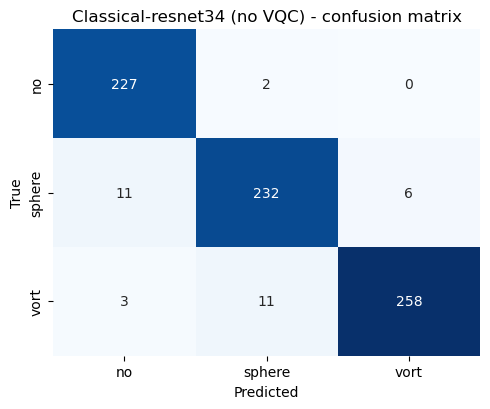

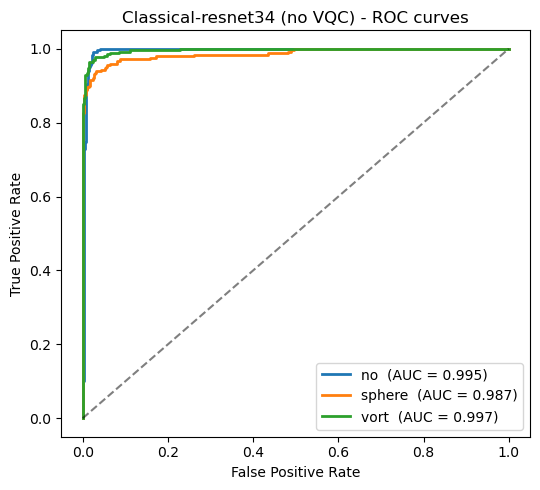

In [15]:
# CELL 15 - Evaluate pure classical model

classical_results = evaluate_full(
    classical_model, test_loader, CLASS_NAMES,
    tag=f"Classical-{CFG['backbone']} (no VQC)",
)

=== Runs included ===
  + Pre+<Backbone>-VQC (Stage 1 -> Stage 2)
  + Pure classical <Backbone> (no VQC)
  + torchquantum_v10 (external reference)

=== Runs missing (skipped) ===
  - ImageNet-only-<Backbone>-VQC (no Stage 1) (run CELL 12 to add)

=== Comparison ===
                                      model  test_accuracy  macro_AUC  macro_precision  macro_recall  macro_F1
                           Pre+resnet34-VQC         0.9600     0.9936           0.9593        0.9610    0.9598
                Classical-resnet34 (no VQC)         0.9560     0.9928           0.9554        0.9572    0.9560
torchquantum_v10 (ResNet18+VQC, no Stage 1)         0.9240     0.9837           0.9241        0.9243    0.9240

=== Quantum-vs-classical analysis ===
Pure classical     | acc=0.9560  AUC=0.9928
Pre+resnet34-VQC | acc=0.9600  AUC=0.9936  (delta acc=+0.0040, delta AUC=+0.0008)

Verdict (Pre+VQC vs pure classical, on test acc): quantum BEATS classical by 0.40 %


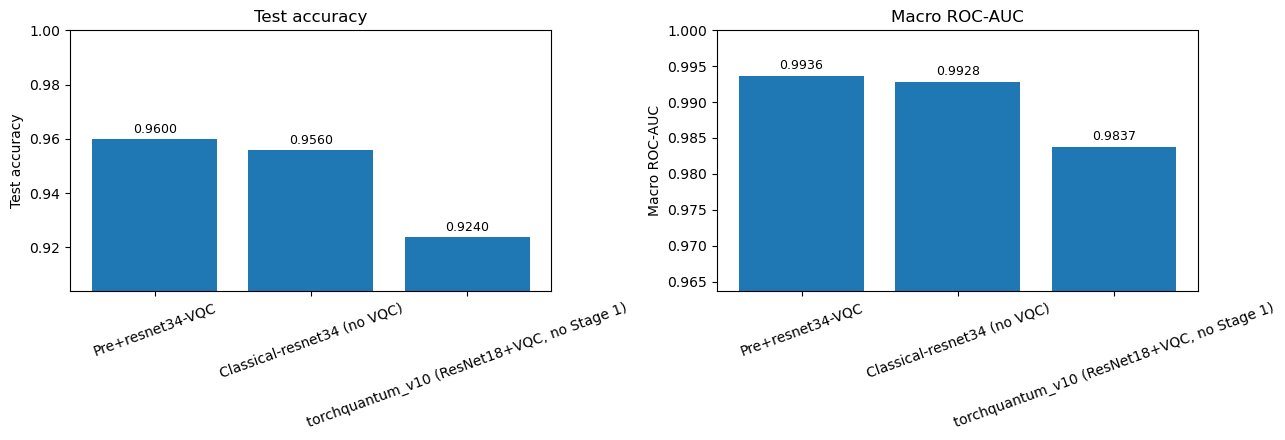

In [16]:
# CELL 16 - Final comparison (robust: skips rows whose run has not been done yet)

TORCHQUANTUM_V10_REF = {
    "tag": "torchquantum_v10 (ResNet18+VQC, no Stage 1)",
    "accuracy": 0.9240,
    "macro_auc": 0.9837,
    "macro_precision": 0.9241,
    "macro_recall": 0.9243,
    "macro_f1": 0.9240,
}


def _row(d):
    return {
        "model": d["tag"],
        "test_accuracy": d.get("accuracy"),
        "macro_AUC": d.get("macro_auc"),
        "macro_precision": d.get("macro_precision"),
        "macro_recall": d.get("macro_recall"),
        "macro_F1": d.get("macro_f1"),
    }


rows = []
present = []
missing = []

for varname, label in [
    ("pre_vqc_results", "Pre+<Backbone>-VQC (Stage 1 -> Stage 2)"),
    ("baseline_results", "ImageNet-only-<Backbone>-VQC (no Stage 1)"),
    ("classical_results", "Pure classical <Backbone> (no VQC)"),
]:
    if varname in globals():
        rows.append(_row(globals()[varname]))
        present.append(label)
    else:
        missing.append((varname, label))

rows.append(_row(TORCHQUANTUM_V10_REF))
present.append("torchquantum_v10 (external reference)")

comparison_df = pd.DataFrame(rows)
for c in ["test_accuracy", "macro_AUC", "macro_precision", "macro_recall", "macro_F1"]:
    comparison_df[c] = pd.to_numeric(comparison_df[c], errors="coerce")

print("=== Runs included ===")
for p in present:
    print(f"  + {p}")
if missing:
    print("\n=== Runs missing (skipped) ===")
    for varname, label in missing:
        cell_hint = {
            "pre_vqc_results": "CELL 11",
            "baseline_results": "CELL 12",
            "classical_results": "CELL 14+15",
        }[varname]
        print(f"  - {label} (run {cell_hint} to add)")

print("\n=== Comparison ===")
print(comparison_df.to_string(index=False, na_rep="-", float_format="%.4f"))

if "pre_vqc_results" in globals() and "classical_results" in globals():
    classical_acc = classical_results["accuracy"]
    pre_vqc_acc = pre_vqc_results["accuracy"]
    classical_auc = classical_results["macro_auc"]
    pre_vqc_auc = pre_vqc_results["macro_auc"]

    print("\n=== Quantum-vs-classical analysis ===")
    print(f"Pure classical     | acc={classical_acc:.4f}  AUC={classical_auc:.4f}")
    if "baseline_results" in globals():
        b_acc = baseline_results["accuracy"]
        b_auc = baseline_results["macro_auc"]
        print(f"ImageNet-only-VQC  | acc={b_acc:.4f}  AUC={b_auc:.4f}  "
              f"(delta acc={b_acc - classical_acc:+.4f}, delta AUC={b_auc - classical_auc:+.4f})")
    print(f"Pre+{CFG['backbone']}-VQC | acc={pre_vqc_acc:.4f}  AUC={pre_vqc_auc:.4f}  "
          f"(delta acc={pre_vqc_acc - classical_acc:+.4f}, delta AUC={pre_vqc_auc - classical_auc:+.4f})")

    verdict = ("BEATS" if pre_vqc_acc > classical_acc
               else "LOSES TO" if pre_vqc_acc < classical_acc else "TIES")
    print(f"\nVerdict (Pre+VQC vs pure classical, on test acc): "
          f"quantum {verdict} classical by {abs(pre_vqc_acc - classical_acc)*100:.2f} %")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
mask_acc = comparison_df["test_accuracy"].notna()
mask_auc = comparison_df["macro_AUC"].notna()

if mask_acc.any():
    sub = comparison_df.loc[mask_acc]
    axes[0].bar(sub["model"], sub["test_accuracy"])
    axes[0].set_ylabel("Test accuracy")
    axes[0].set_ylim(max(0.0, sub["test_accuracy"].min() - 0.02), 1.0)
    axes[0].set_title("Test accuracy")
    axes[0].tick_params(axis="x", rotation=20)
    for i, v in enumerate(sub["test_accuracy"]):
        axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

if mask_auc.any():
    sub = comparison_df.loc[mask_auc]
    axes[1].bar(sub["model"], sub["macro_AUC"])
    axes[1].set_ylabel("Macro ROC-AUC")
    axes[1].set_ylim(max(0.0, sub["macro_AUC"].min() - 0.02), 1.0)
    axes[1].set_title("Macro ROC-AUC")
    axes[1].tick_params(axis="x", rotation=20)
    for i, v in enumerate(sub["macro_AUC"]):
        axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()